In [2]:
import numpy as np
import os
import yaml
from pprint import pprint 
import shutil
import pickle


noise_lst = [round(0.1*i,1) for i in range(1,11)]
data_type_lst = [
    '800_0_interval_4096_noiseRatio_0.0',
    '800_0_interval_4096_noiseRatio_0.1',
    '800_0_interval_4096_noiseRatio_0.2',
    '800_0_interval_4096_noiseRatio_0.3',
    '800_45_interval_4096_noiseRatio_0.0',
    '800_45_interval_4096_noiseRatio_0.1',
    '800_45_interval_4096_noiseRatio_0.2',
    '800_45_interval_4096_noiseRatio_0.3',
    'FEed_800_0_interval_4096_noiseRatio_0.0',
    'FEed_800_0_interval_4096_noiseRatio_0.1',
    'FEed_800_0_interval_4096_noiseRatio_0.2',
    'FEed_800_0_interval_4096_noiseRatio_0.3',
    'FEed_800_45_interval_4096_noiseRatio_0.0',
    'FEed_800_45_interval_4096_noiseRatio_0.1',
    'FEed_800_45_interval_4096_noiseRatio_0.2',
    'FEed_800_45_interval_4096_noiseRatio_0.3'
]

def open_yaml(yaml_path):
    with open(yaml_path) as f:
        film = yaml.load(f, Loader=yaml.FullLoader)
        return film

def check_condition(condition_gt,condition_each):
    
    false_dict = {}  
    for condition_k,condition_v in condition_gt.items():
        
        if condition_gt[condition_k] != condition_each.get(condition_k):
            false_dict[condition_k] = condition_each.get(condition_k)
            
    bool_value = True
    if len(false_dict.keys()) != 0:
        bool_value = False
            
    return false_dict, bool_value

def open_pkl(pkl_path):
    
    with open(pkl_path,'rb') as F:
        opened_pkl = pickle.load(F)
        
    return opened_pkl
        

result_dict = {}
test_results_only_dict = {}
for data_type in data_type_lst:

    for noise_value in noise_lst:
        
        if data_type in [
            '800_0_interval_4096_noiseRatio_0.0',
            '800_0_interval_4096_noiseRatio_0.1',
            '800_0_interval_4096_noiseRatio_0.2',
            '800_0_interval_4096_noiseRatio_0.3',
            '800_45_interval_4096_noiseRatio_0.0',
            '800_45_interval_4096_noiseRatio_0.1',
            '800_45_interval_4096_noiseRatio_0.2',
            '800_45_interval_4096_noiseRatio_0.3'
        ]:
            input_size = 4096
            root_path = './history/test_bed_raw/denoising_dsvdd'
            each_result_key = '_'.join(
                [
                    data_type,
                    f'noise_ratio_{str(noise_value)}'
                ]
            )
            upper_path = os.path.join(
                root_path,
                data_type,
                f'noise_{noise_value}',
            )
        elif data_type in [
            'FEed_800_0_interval_4096_noiseRatio_0.0',
            'FEed_800_0_interval_4096_noiseRatio_0.1',
            'FEed_800_0_interval_4096_noiseRatio_0.2',
            'FEed_800_0_interval_4096_noiseRatio_0.3',
            'FEed_800_45_interval_4096_noiseRatio_0.0',
            'FEed_800_45_interval_4096_noiseRatio_0.1',
            'FEed_800_45_interval_4096_noiseRatio_0.2',
            'FEed_800_45_interval_4096_noiseRatio_0.3'
        ]:
            input_size = 27
            root_path = './history/test_bed_FEed/denoising_dsvdd_FEed_result_20241020_final'
            each_result_key = '_'.join(
                [
                    data_type,
                    'normal_label_0',
                    f'noise_ratio_{str(noise_value)}'
                ]
            )
            upper_path = os.path.join(
                root_path,
                data_type,
                f'normal_label_0',
                f'noise_{noise_value}',
            )
        else:
            raise Exception('wrong data_type')
        
        result_dict[each_result_key] = []
        
        each_condition = {
            'data_type':data_type,
            'normal_label':label,
            'noise_ratio':noise_value,
            'inputSize':input_size,
            'do_zScore':True,
            'which_model':'denoising_dsvdd',
            'useMax_when_val':False,
        }
        if os.path.exists(upper_path):
                
            under_path_lst = os.listdir(upper_path)
            
            for under_path in under_path_lst:
                
                each_path = os.path.join(
                    upper_path,
                    under_path
                )
                config_path = os.path.join(
                    each_path,
                    'configs',
                    'resultConfig.yaml'
                )
                test_result_arr_path = os.path.join(
                    each_path,
                    'test_result_only.pkl'
                )
                
                flg = 0
                if os.path.exists(config_path):
                    loaded_yaml = open_yaml(config_path)
                    
                    for k,v in each_condition.items():
                        if str(loaded_yaml.get(k)) in ['true','false']:
                            print(k,v)
                            
                    condition_checked,bool_value = check_condition(
                            condition_gt=each_condition,
                            condition_each=loaded_yaml
                        )
                    
                    if len(condition_checked.keys()) !=0:
                        
                        shutil.rmtree(each_path)
                        
                        print(f'this path removed {each_path}')
                    else:
                        result_dict[each_result_key].append(each_path)
                        
                else:
                    print(f'there is no config in {each_path}')
                    shutil.rmtree(each_path)
                    
                if os.path.exists(test_result_arr_path) is False:
                    print(each_path)
                    
                else:
                    result_pkl = open_pkl(test_result_arr_path)
                        
                    test_only_key = '___'.join(
                        [
                            'denoising_dsvdd',
                            data_type,
                            f'normal_label_{label}',
                            f'noise_ratio_{str(noise_value)}'
                        ]
                    )
                    if test_only_key not in test_results_only_dict.keys():
                        
                        test_results_only_dict[test_only_key] = result_pkl['test_label']
                    else:
                    
                        is_test_eq= np.array_equal(
                            test_results_only_dict[test_only_key],
                            result_pkl['test_label']
                        )
                        if is_test_eq is False:
                            print(test_result_arr_path)
                        
                        # mask = result_pkl['test_label'] == 0
                        # print(result_pkl.keys())
                        # print(result_pkl['test_score'][mask].shape)
        else:
            print(f'there is no {upper_path}')    
        
        # print(data_type,label,noise_value,'  complete')    
        
print(data_type,' complete')

for k,v in result_dict.items():
    if len(v) <10:
        print(k,len(v))
# for k,v in result_dict.items():
    # print(k,len(v))
    
# with open('./denoise_results_image_ver.pkl','wb') as F:
#     pickle.dump(test_results_only_dict,F)
#     print('all complete')
                    

there is no ./history/test_bed_raw/denoising_dsvdd/800_0_interval_4096_noiseRatio_0.0/noise_1.0
there is no ./history/test_bed_raw/denoising_dsvdd/800_0_interval_4096_noiseRatio_0.1/noise_1.0
there is no ./history/test_bed_raw/denoising_dsvdd/800_0_interval_4096_noiseRatio_0.2/noise_1.0
there is no ./history/test_bed_raw/denoising_dsvdd/800_0_interval_4096_noiseRatio_0.3/noise_1.0
there is no ./history/test_bed_raw/denoising_dsvdd/800_45_interval_4096_noiseRatio_0.0/noise_1.0
there is no ./history/test_bed_raw/denoising_dsvdd/800_45_interval_4096_noiseRatio_0.1/noise_1.0
there is no ./history/test_bed_raw/denoising_dsvdd/800_45_interval_4096_noiseRatio_0.2/noise_1.0
there is no ./history/test_bed_raw/denoising_dsvdd/800_45_interval_4096_noiseRatio_0.3/noise_1.0
FEed_800_45_interval_4096_noiseRatio_0.3  complete
800_0_interval_4096_noiseRatio_0.0_noise_ratio_0.1 0
800_0_interval_4096_noiseRatio_0.0_noise_ratio_0.2 0
800_0_interval_4096_noiseRatio_0.0_noise_ratio_0.3 0
800_0_interval_409

In [3]:
import numpy as np
import os
import yaml
from pprint import pprint 
import pickle
import shutil
label_lst = [i for i in range(10)]
# noise_lst = [round(0.1*i,1) for i in range(1,11)]
data_type_lst = ['cifar_1','cifar_2','mnist_1','mnist_2','cifar_yes','mnist_yes']
# data_type_lst = ['cifar_yes','mnist_yes']

algo_lst = ['smoothed_dsvdd','vanilla_dsvdd','ocsvm']

def open_yaml(yaml_path):
    with open(yaml_path) as f:
        film = yaml.load(f, Loader=yaml.FullLoader)
        return film

def check_condition(condition_gt,condition_each):
    
    false_dict = {}  
    for condition_k,condition_v in condition_gt.items():
        
        if condition_gt[condition_k] != condition_each.get(condition_k):
            false_dict[condition_k] = condition_each.get(condition_k)
            
    bool_value = True
    if len(false_dict.keys()) != 0:
        bool_value = False
            
    return false_dict, bool_value

def open_pkl(pkl_path):
    
    with open(pkl_path,'rb') as F:
        opened_pkl = pickle.load(F)
        
    return opened_pkl
        
result_dict = {}
test_results_only_dict = {}

for algo in algo_lst:
    
    for data_type in data_type_lst:
        for label in label_lst:
            
            if data_type in ['cifar_1','cifar_2','cifar_yes']:
                input_size = 3072
            elif data_type in ['mnist_1','mnist_2','mnist_yes']:
                input_size = 784
            else:
                raise Exception('wrong data type')
                
            if data_type in ['cifar_1','cifar_2','mnist_1','mnist_2']:
                root_path = f'./history/{algo}_image_noised_new_start/'
            elif data_type in ['cifar_yes','mnist_yes']:
                root_path = f'./history/{algo}_image_non_noise_new_start/'
            else:
                raise Exception('wrong data type 2')
                
            each_result_key = '_'.join(
                [
                    algo,
                    data_type,
                    f'normal_label_{label}'
                ]
            )
            result_dict[each_result_key] = []
            
            each_condition = {
                'data_type':data_type,
                'normal_label':label,
                'inputSize':input_size,
                'do_zScore':True,
                'which_model': algo,
                'useMax_when_val':False,
            }
            upper_path = os.path.join(
                root_path,
                data_type,
                f'normal_label_{label}'
            )

            if os.path.exists(upper_path):
                    
                under_path_lst = os.listdir(upper_path)
                
                for under_path in under_path_lst:
                    
                    each_path = os.path.join(
                        upper_path,
                        under_path
                    )
                    config_path = os.path.join(
                        each_path,
                        'configs',
                        'resultConfig.yaml'
                    )
                    test_result_arr_path = os.path.join(
                        each_path,
                        'test_result_only.pkl'
                    )
                    
                    
                    flg = 0
                    if os.path.exists(config_path):
                        loaded_yaml = open_yaml(config_path)
                        
                        for k,v in each_condition.items():
                            if str(loaded_yaml.get(k)) in ['true','false']:
                                print(k,v)
                                
                        condition_checked,bool_value = check_condition(
                                condition_gt=each_condition,
                                condition_each=loaded_yaml
                            )
                        
                        if len(condition_checked.keys()) !=0:
                            print(condition_checked,1111111)
                            shutil.rmtree(each_path)
                            # print()
                            pass
                            # print(f'this path removed {each_path}')
                        else:
                            result_dict[each_result_key].append(each_path)
                            
                    else:
                        print(f'there is no config in {each_path}')
                        # shutil.rmtree(each_path)
                        
                    if os.path.exists(test_result_arr_path) is False:
                        print(each_path)
                    else:
                        
                        result_pkl = open_pkl(test_result_arr_path)
                        
                        test_only_key = '___'.join(
                            [
                                algo,
                                data_type,
                                f'normal_label_{label}',
                                # f'noise_ratio_{str(noise_value)}'
                            ]
                        )
                        if test_only_key not in test_results_only_dict.keys():
                            test_results_only_dict[test_only_key] = result_pkl['test_label']
                        else:
                            
                            is_test_eq= np.array_equal(
                                test_results_only_dict[test_only_key],
                                result_pkl['test_label']
                            )
                            if is_test_eq is False:
                                print(test_result_arr_path)
                        
            else:
                print(f'there is no {upper_path}')    
        
    print(algo,data_type,label,'  complete ')
                    
for k,v in result_dict.items():
    if len(v) <10:
        print(k,len(v))
    # for k,v in result_dict.items():
    #     print(k,len(v))
            
    # print(f'{algo} done')

# for k,v in result_dict.items():
#     print(k,len(v))

with open('./other_algo_results_image_ver.pkl','wb') as F:
    pickle.dump(test_results_only_dict,F)
    print('all complete')                        

smoothed_dsvdd mnist_yes 9   complete 
vanilla_dsvdd mnist_yes 9   complete 
ocsvm mnist_yes 9   complete 
smoothed_dsvdd_mnist_yes_normal_label_0 9
smoothed_dsvdd_mnist_yes_normal_label_2 9
smoothed_dsvdd_mnist_yes_normal_label_3 9
smoothed_dsvdd_mnist_yes_normal_label_4 9
smoothed_dsvdd_mnist_yes_normal_label_5 9
smoothed_dsvdd_mnist_yes_normal_label_9 9
vanilla_dsvdd_mnist_yes_normal_label_1 9
vanilla_dsvdd_mnist_yes_normal_label_2 9
vanilla_dsvdd_mnist_yes_normal_label_3 9
vanilla_dsvdd_mnist_yes_normal_label_4 9
vanilla_dsvdd_mnist_yes_normal_label_5 9
vanilla_dsvdd_mnist_yes_normal_label_6 9
vanilla_dsvdd_mnist_yes_normal_label_7 9
vanilla_dsvdd_mnist_yes_normal_label_8 9
ocsvm_mnist_yes_normal_label_0 9
all complete


In [ ]:
# import os
# import pickle

# def open_pkl(pkl_path):
    
#     with open(pkl_path,'rb') as F:
#         opened_pkl = pickle.load(F)
        
#     return opened_pkl

# denoise_pkl = open_pkl(
#     './denoise_results_tmp.pkl'
# )
# etc_pkl = open_pkl(
#     './etc_results_tmp.pkl'
# )
# total_label_dict = {}

# total_label_dict.update(denoise_pkl)
# total_label_dict.update(etc_pkl)


# for k,v in total_label_dict.items():
#     print(k,len(v))

# with open('./total_label_arr_only_dict.pkl','wb') as F:
#     pickle.dump(total_label_dict,F)
    
# print('done')

In [23]:
# import os
# import pickle

# def open_pkl(pkl_path):
    
#     with open(pkl_path,'rb') as F:
#         opened_pkl = pickle.load(F)
        
#     return opened_pkl

# total_label_dict = open_pkl(
#     './total_label_arr_only_dict.pkl'
# )


# total_label_mask_dict = {}
# for k,v in total_label_dict.items():
    
    



(28, 28) 255


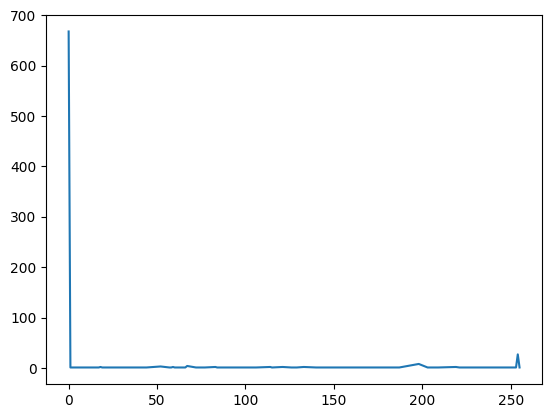

255.0 0.0
255 0
<class 'torch.Tensor'> torch.Size([28, 28])


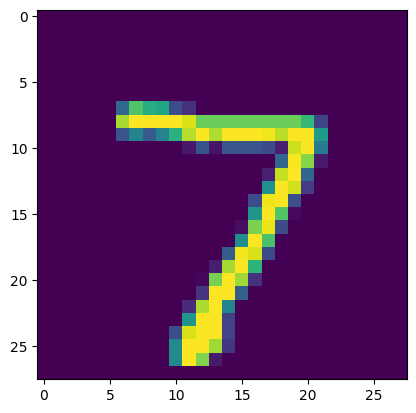

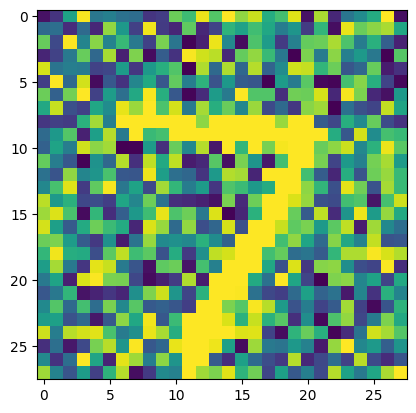

(28, 28) 255


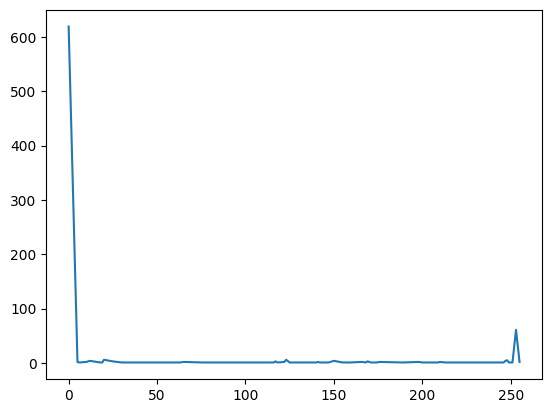

255.0 1.0
255 1
<class 'torch.Tensor'> torch.Size([28, 28])


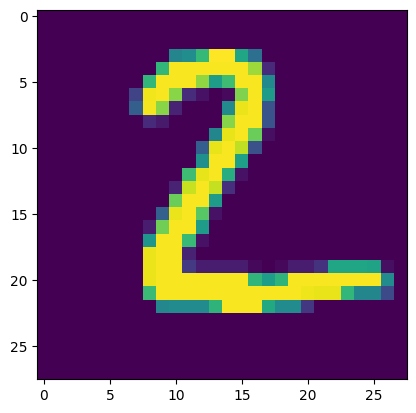

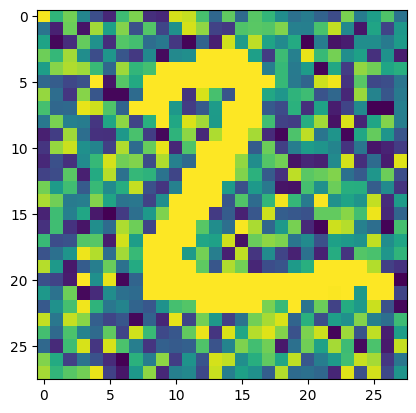

(28, 28) 255


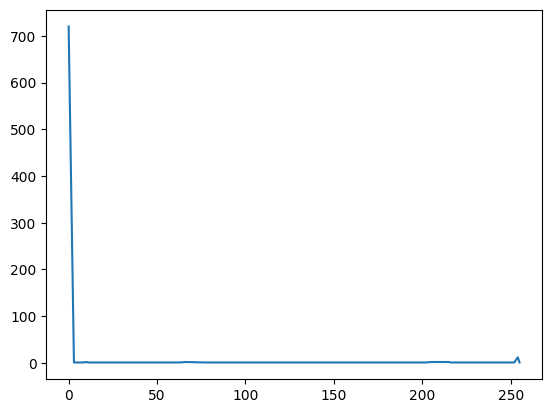

255.0 0.0
255 0
<class 'torch.Tensor'> torch.Size([28, 28])


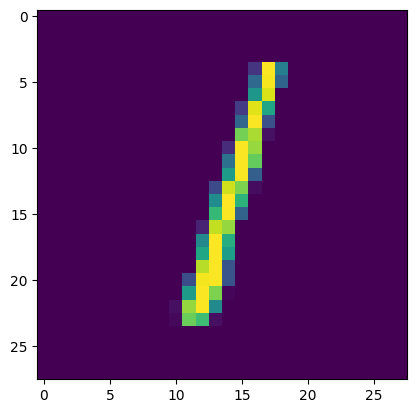

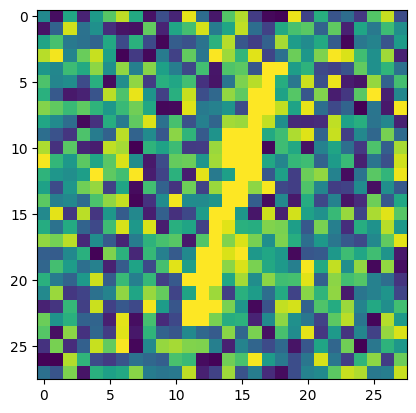

(28, 28) 255


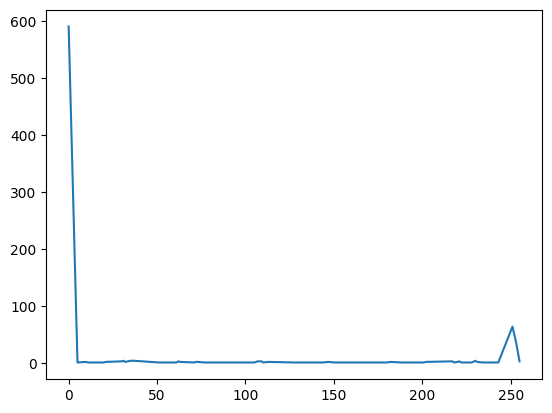

255.0 0.0
255 0
<class 'torch.Tensor'> torch.Size([28, 28])


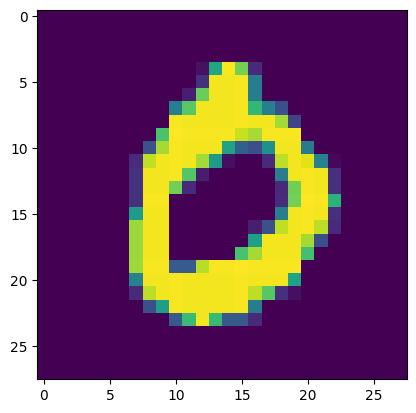

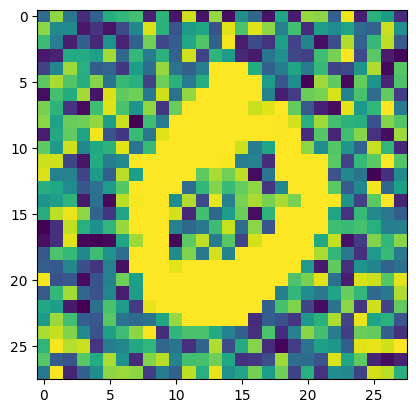

(28, 28) 255


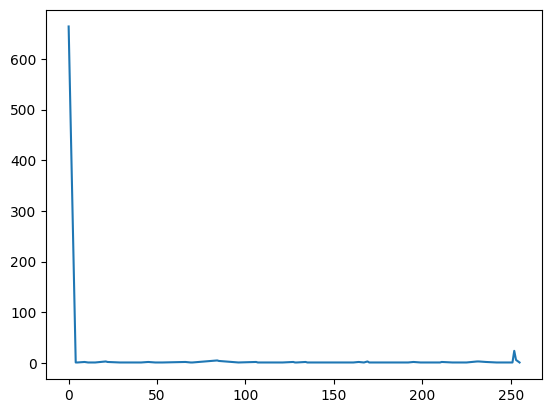

254.0 0.0
255 0
<class 'torch.Tensor'> torch.Size([28, 28])


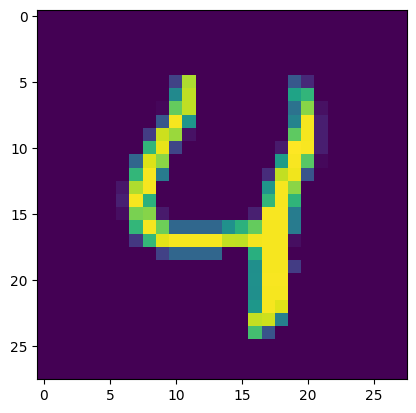

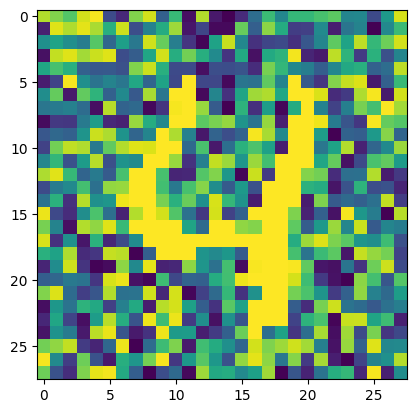

In [127]:
import torch
from torchvision import datasets, transforms
import numpy as np

trainData = datasets.MNIST(root = './test_run2',
                            train=False,
                            download=True
)
                                

noise_ratio = 2
import matplotlib.pyplot as plt
flg =0 
for each_train_data in trainData:
        
    each_x = np.array(each_train_data[0])
    print(each_x.shape,np.max(each_x))
    
    uniq_value,uniq_count = np.unique(each_x,return_counts=True)
    plt.plot(uniq_value,uniq_count)
    plt.show()
    each_y = each_train_data[1]
    
    noise = np.round(0.5*noise_ratio* np.random.randint(0,256,(each_x.shape)))
    print(np.max(noise),np.min(noise))
    noised_x = np.clip(each_x + noise,0,255).astype(int)
    print(np.max(noised_x),np.min(noised_x))
    
    tensor_x = torch.from_numpy(noised_x)
    print(type(tensor_x),tensor_x.size())
    
    plt.imshow( each_x)
    plt.show()
    plt.close()
    plt.imshow(  noised_x )
    plt.show()
    plt.close()
    flg += 1
    if flg >= 5:
        break



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


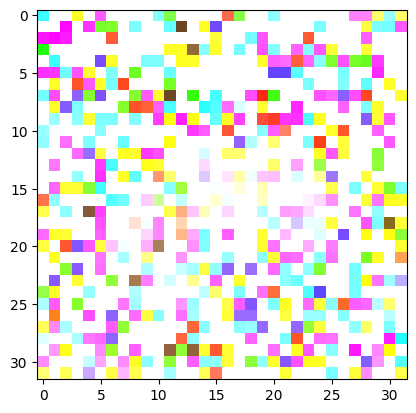

In [101]:
import os
import pickle

def open_pkl(pkl_path):
    
    with open(pkl_path,'rb') as F:
        opened_pkl = pickle.load(F)
        
    return opened_pkl

test_path= '/home/asdflkj3123/mainDir/forUni/theDir1/DeepLearningFinal/newDataVer0/scripts/data_download_path/noisedData/cifar/train/noise_1.pickle'

opened_test= open_pkl(test_path)
import matplotlib.pyplot as plt

plt.imshow( opened_test[0][0].permute(1,2,0))
plt.show()
plt.close()
